In [1]:
import numpy as np
np.array([1,2,3]) * 2

array([2, 4, 6])

Vectorization means performing operations on entire datasets without loops.
It makes computations faster and is widely used in AI models.

# Day 4: Pre-processing Techniques

In [1]:
import pandas as pd

data = {
    'Age': [21, None, 23, 24],
    'Score': [80, 75, None, 95]
}

df = pd.DataFrame(data)

df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Score'] = df['Score'].fillna(0)

df

,Age,Score
0,21.000000,80.0
1,22.666667,75.0
2,23.000000,0.0
3,24.000000,95.0


Filling missing values with the mean is better than using 0 because 0 can distort the data.
The mean maintains the overall distribution and helps the model learn more accurate patterns.

# Day 5: Linear Regression & Evaluation

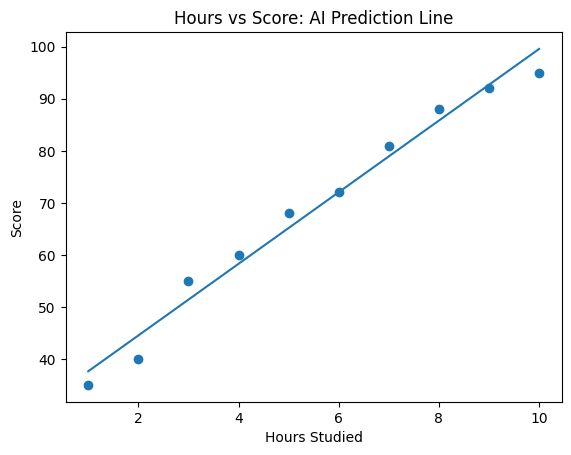

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Dataset
data = {
    'Hours': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Score': [35, 40, 55, 60, 68, 72, 81, 88, 92, 95]
}

df = pd.DataFrame(data)

X = df[['Hours']]
y = df['Score']

model = LinearRegression()
model.fit(X, y)

# Plot
plt.scatter(X, y)
plt.plot(X, model.predict(X))
plt.title("Hours vs Score: AI Prediction Line")
plt.xlabel("Hours Studied")
plt.ylabel("Score")
plt.show()

If we train the model with only 2 rows of data instead of 8, the model will have less information to learn the pattern. This can lead to inaccurate predictions and poor generalization on new data.

# Day 6: Logistic Regression & Classification Metrics

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Dataset
data = {
    'Hours_Sleep': [8, 7, 6, 5, 8, 4, 9, 5, 6, 4],
    'Coffee_Cups': [1, 2, 2, 4, 0, 5, 1, 4, 3, 6],
    'Passed': [1, 1, 1, 0, 1, 0, 1, 0, 0, 0]
}

df = pd.DataFrame(data)

X = df[['Hours_Sleep', 'Coffee_Cups']]
y = df['Passed']

# Train model
clf = LogisticRegression()
clf.fit(X, y)

# Custom test
manual_input = pd.DataFrame({
    'Hours_Sleep': [3],
    'Coffee_Cups': [7]
})

prediction = clf.predict(manual_input)
print("Prediction for [3 hrs sleep, 7 coffees]:", prediction)

Prediction for [3 hrs sleep, 7 coffees]: [0]


## Reflection

In cancer detection, a False Negative is more dangerous than a False Positive.

A False Negative means the AI fails to detect an actual cancer case, which can delay treatment and seriously affect the patient’s health.

A False Positive may cause temporary stress or extra tests, but it is safer than missing a real disease.

# Day 8: California Housing Project

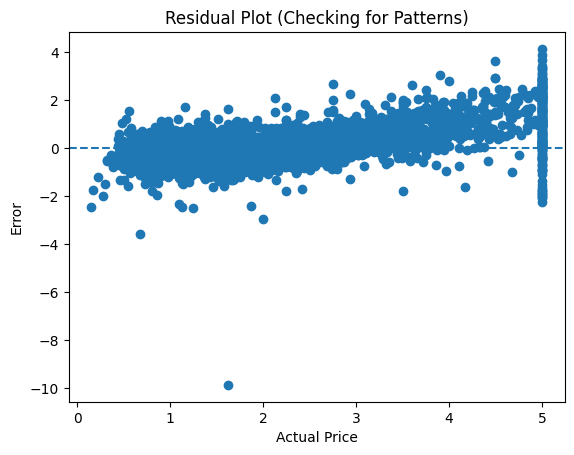

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Load data
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseVal'] = data.target

# Features & target
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predict
predictions = model.predict(X_test_scaled)

# Residuals
residuals = y_test - predictions

# Plot
plt.scatter(y_test, residuals)
plt.axhline(y=0, linestyle='--')

plt.title("Residual Plot (Checking for Patterns)")
plt.xlabel("Actual Price")
plt.ylabel("Error")

plt.show()

If the residual plot shows a U-shape, it means the linear model is not suitable because the relationship between features and target is non-linear. The model is unable to capture the pattern properly.

# Day 9: Model Optimization & Grid Search

In [3]:
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# Load dataset
data = fetch_california_housing()

X = data.data
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Default model
default_model = Ridge()
default_model.fit(X_train_scaled, y_train)

default_preds = default_model.predict(X_test_scaled)
default_r2 = r2_score(y_test, default_preds)

# Grid Search
param_grid = {'alpha': [0.1, 1.0, 10.0, 100.0, 500.0]}

grid_search = GridSearchCV(Ridge(), param_grid, cv=5, scoring='r2')
grid_search.fit(X_train_scaled, y_train)

# Best model
best_model = grid_search.best_estimator_
best_preds = best_model.predict(X_test_scaled)
best_r2 = r2_score(y_test, best_preds)

# Results
print("Default R2:", round(default_r2, 4))
print("Optimized R2:", round(best_r2, 4))
print("Best Alpha:", grid_search.best_params_)

Default R2: 0.5758
Optimized R2: 0.5758
Best Alpha: {'alpha': 0.1}


Using a wider range of values first helps identify the general scale where the best parameter lies. 
If we start with small increments, we might miss the optimal region entirely. 
A broad search helps locate the best zone, after which fine-tuning can be done.

# Day 10: Non-Linear Models & Overfitting

R2 Score (Depth=2): 0.8133
R2 Score (Depth=5): 0.9295
R2 Score (Depth=20): 1.0


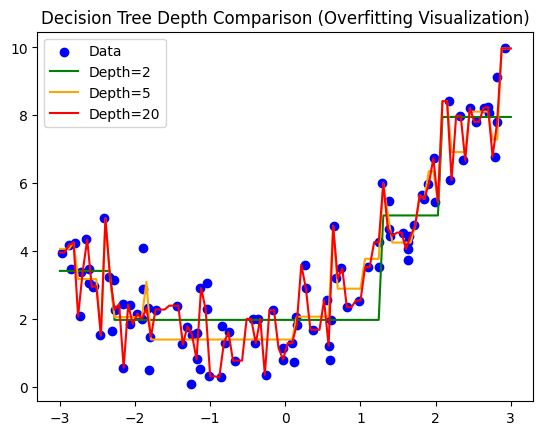

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

np.random.seed(42)

# Generate data
X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(100, 1)

# Prediction range
X_new = np.linspace(-3, 3, 100).reshape(100, 1)

# Depth values
depths = [2, 5, 20]
colors = ['green', 'orange', 'red']

plt.figure()
plt.scatter(X, y, color='blue', label='Data')

for depth, color in zip(depths, colors):
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    tree.fit(X, y)

    y_pred = tree.predict(X_new)
    plt.plot(X_new, y_pred, color=color, label=f"Depth={depth}")

    r2 = r2_score(y, tree.predict(X))
    print(f"R2 Score (Depth={depth}):", round(r2, 4))

plt.legend()
plt.title("Decision Tree Depth Comparison (Overfitting Visualization)")
plt.show()

A jittery model that closely follows every data point is not desirable because it indicates overfitting. Instead of learning the underlying pattern, the model memorizes noise present in the training data. This leads to poor performance on unseen data. A smoother model, on the other hand, captures the general trend and is more reliable for real-world predictions.

# Day 11: Random Forests & Feature Importance

In [3]:
import time
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Load data (MISSING PART)
data = fetch_california_housing()

X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)

# Tree count experiment
tree_counts = [10, 50, 200]

for n in tree_counts:
    start = time.time()
    
    model = RandomForestRegressor(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    
    end = time.time()
    
    print(f"Trees: {n}")
    print(f"R2 Score: {round(r2,4)}")
    print(f"Training Time: {round(end - start, 2)} sec\n")

Trees: 10
R2 Score: 0.7831
Training Time: 1.56 sec

Trees: 50
R2 Score: 0.8037
Training Time: 7.56 sec

Trees: 200
R2 Score: 0.8062
Training Time: 31.3 sec



As the number of trees increases, the model performance improves initially. However, after a certain point, the improvement becomes very small while the training time increases significantly. This is known as diminishing returns, where adding more trees increases computational cost without substantial gain in accuracy.

# Day 12: Logistic Regression & Classification Metrics

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Load data
data = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# Probability prediction
probs = model.predict_proba(X_test_scaled)

print(probs[:5])

[[1.13590250e-01 8.86409750e-01]
 [9.99990991e-01 9.00936206e-06]
 [9.96920905e-01 3.07909541e-03]
 [5.10134225e-04 9.99489866e-01]
 [6.06389713e-05 9.99939361e-01]]


In a medical scenario like cancer detection, a False Negative is more dangerous than a False Positive. A False Negative means the model incorrectly predicts that a patient is healthy when they are actually sick, which can delay treatment and lead to serious consequences. A False Positive may cause temporary stress or additional tests, but it is less harmful compared to missing a real disease.

# DAY 15: K-MEANS CLUSTERING